In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report, 
                             confusion_matrix, RocCurveDisplay)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

X = pd.read_csv('../data/X_processed.csv')
y = pd.read_csv('../data/y_processed.csv').squeeze()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Churn rate:", y.mean().round(4))

X shape: (7043, 34)
y shape: (7043,)
Churn rate: 0.2654


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nChurn rate in train:", y_train.mean().round(4))
print("Churn rate in test:", y_test.mean().round(4))

Training set: (5634, 34)
Test set: (1409, 34)

Churn rate in train: 0.2654
Churn rate in test: 0.2654


In [3]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

lr_auc = roc_auc_score(y_test, lr_probs)

print(f"Logistic Regression ROC-AUC: {lr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds))

Logistic Regression ROC-AUC: 0.8476

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



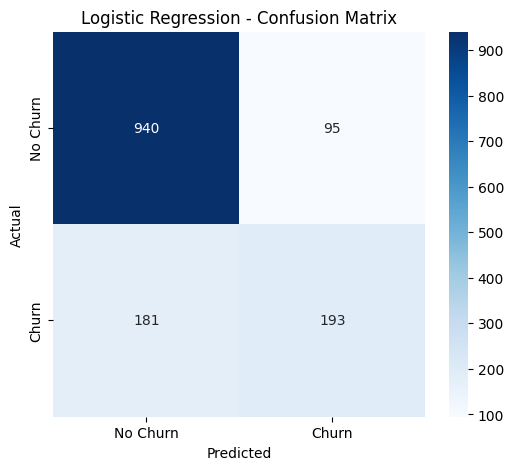


True Negatives  (correctly predicted no churn): 940
False Positives (wrongly predicted churn):      95
True Positives  (correctly predicted churn):    193
False Negatives (missed churners):              181


In [4]:
cm = confusion_matrix(y_test, lr_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../reports/lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly predicted no churn): {tn}")
print(f"False Positives (wrongly predicted churn):      {fp}")
print(f"True Positives  (correctly predicted churn):    {tp}")
print(f"False Negatives (missed churners):              {fn}")

In [5]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    eval_metric='auc'
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

xgb_auc = roc_auc_score(y_test, xgb_probs)

print(f"XGBoost ROC-AUC: {xgb_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds))

XGBoost ROC-AUC: 0.8328

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1035
           1       0.51      0.75      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409



In [6]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'scale_pos_weight': [1, 2, 3]
}

xgb_base = XGBClassifier(random_state=42, eval_metric='auc')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best Parameters:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_.round(4))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 0.7, 'scale_pos_weight': 1, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
Best CV ROC-AUC: 0.8495


In [7]:
xgb_tuned = XGBClassifier(
    subsample=0.7,
    scale_pos_weight=1,
    n_estimators=500,
    max_depth=4,
    learning_rate=0.01,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric='auc'
)

xgb_tuned.fit(X_train, y_train)

xgb_tuned_preds = xgb_tuned.predict(X_test)
xgb_tuned_probs = xgb_tuned.predict_proba(X_test)[:, 1]

xgb_tuned_auc = roc_auc_score(y_test, xgb_tuned_probs)

print(f"Tuned XGBoost ROC-AUC: {xgb_tuned_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_tuned_preds))

Tuned XGBoost ROC-AUC: 0.8453

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [8]:
models = {
    'Logistic Regression': (lr_probs, lr_preds),
    'XGBoost Default':     (xgb_probs, xgb_preds),
    'XGBoost Tuned':       (xgb_tuned_probs, xgb_tuned_preds)
}

print(f"{'Model':<25} {'ROC-AUC':>10} {'Recall':>10} {'Precision':>10} {'F1':>10}")
print("-" * 65)

for name, (probs, preds) in models.items():
    auc = roc_auc_score(y_test, probs)
    report = classification_report(y_test, preds, output_dict=True)
    recall = report['1']['recall']
    precision = report['1']['precision']
    f1 = report['1']['f1-score']
    print(f"{name:<25} {auc:>10.4f} {recall:>10.4f} {precision:>10.4f} {f1:>10.4f}")

Model                        ROC-AUC     Recall  Precision         F1
-----------------------------------------------------------------
Logistic Regression           0.8476     0.5160     0.6701     0.5831
XGBoost Default               0.8328     0.7540     0.5090     0.6078
XGBoost Tuned                 0.8453     0.5160     0.6565     0.5778


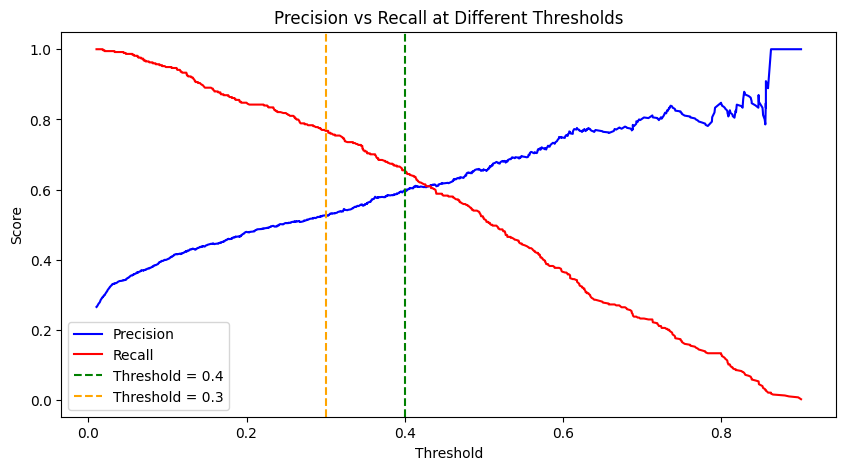

Threshold 0.3 → Recall: 0.7674 | Precision: 0.5266 | F1: 0.6246
Threshold 0.4 → Recall: 0.6524 | Precision: 0.5966 | F1: 0.6232
Threshold 0.5 → Recall: 0.5160 | Precision: 0.6565 | F1: 0.5778


In [9]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_tuned_probs)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='red')
plt.axvline(x=0.4, color='green', linestyle='--', label='Threshold = 0.4')
plt.axvline(x=0.3, color='orange', linestyle='--', label='Threshold = 0.3')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at Different Thresholds')
plt.legend()
plt.savefig('../reports/precision_recall_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

# Try different thresholds
for threshold in [0.3, 0.4, 0.5]:
    preds_thresh = (xgb_tuned_probs >= threshold).astype(int)
    report = classification_report(y_test, preds_thresh, output_dict=True)
    auc = roc_auc_score(y_test, xgb_tuned_probs)
    print(f"Threshold {threshold} → Recall: {report['1']['recall']:.4f} | "
          f"Precision: {report['1']['precision']:.4f} | "
          f"F1: {report['1']['f1-score']:.4f}")

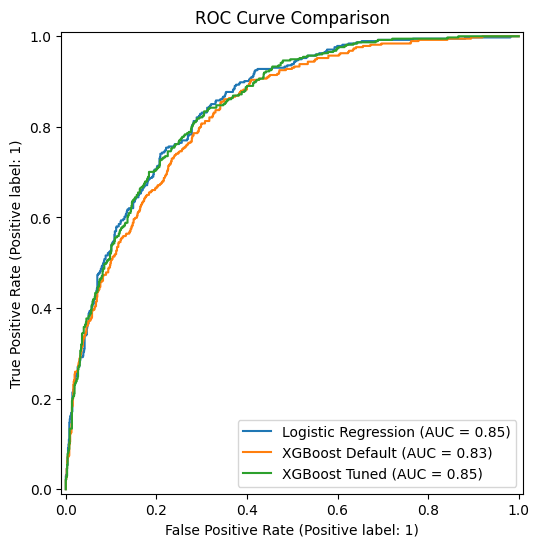

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, lr_probs, 
                                  name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, xgb_probs, 
                                  name='XGBoost Default', ax=ax)
RocCurveDisplay.from_predictions(y_test, xgb_tuned_probs, 
                                  name='XGBoost Tuned', ax=ax)

plt.title('ROC Curve Comparison')
plt.savefig('../reports/roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pickle
from sklearn.preprocessing import StandardScaler

numerical_cols = ['tenure', 'MonthlyCharges', 
                  'charges_to_tenure_ratio', 'service_adoption_score']

scaler = StandardScaler()
scaler.fit(X_train[numerical_cols])

with open('../models/churn_model.pkl', 'wb') as f:
    pickle.dump(xgb_tuned, f)

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Models saved successfully")
print("\nFinal Model Summary:")
print(f"  Algorithm:        XGBoost Tuned")
print(f"  ROC-AUC:          0.8453")
print(f"  Recall @ 0.3:     0.7674")
print(f"  Precision @ 0.3:  0.5266")
print(f"  Threshold:        0.3")
print(f"  Features:         {X_train.shape[1]}")
print(f"  Training samples: {X_train.shape[0]}")

Models saved successfully!

Final Model Summary:
  Algorithm:        XGBoost Tuned
  ROC-AUC:          0.8453
  Recall @ 0.3:     0.7674
  Precision @ 0.3:  0.5266
  Threshold:        0.3
  Features:         34
  Training samples: 5634


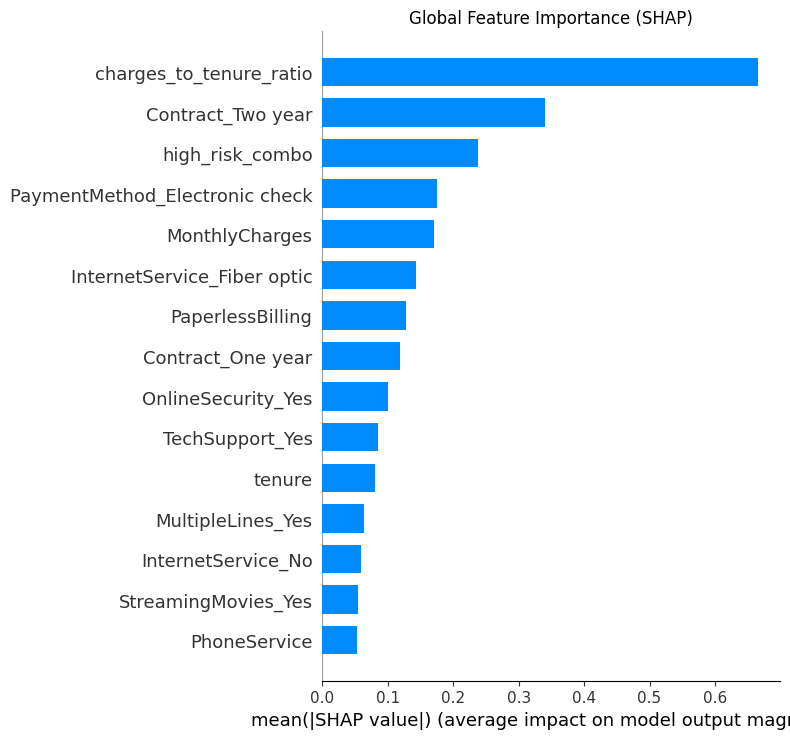

In [12]:
import shap

explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", 
                  max_display=15, show=False)
plt.title('Global Feature Importance (SHAP)')
plt.tight_layout()
plt.savefig('../reports/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

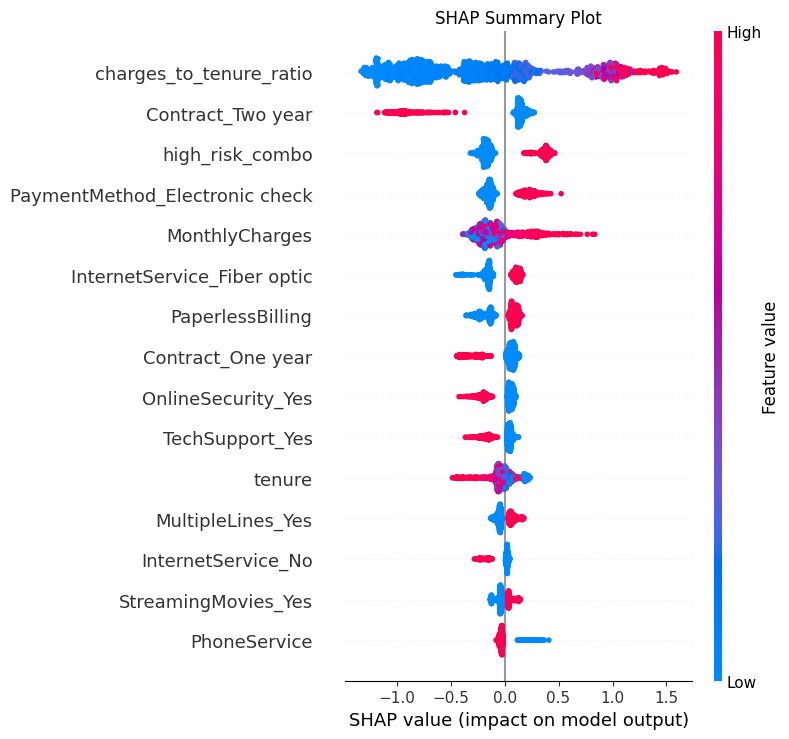

In [13]:
plt.figure()
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.savefig('../reports/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(xgb_tuned, X_train, y_train, 
                             cv=cv, scoring='roc_auc', n_jobs=-1)

print("Cross Validation ROC-AUC Scores:")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: {score:.4f}")
print(f"\nMean:  {cv_scores.mean():.4f}")
print(f"Std:   {cv_scores.std():.4f}")
print(f"Range: {cv_scores.min():.4f} - {cv_scores.max():.4f}")

Cross Validation ROC-AUC Scores:
  Fold 1: 0.8452
  Fold 2: 0.8325
  Fold 3: 0.8463
  Fold 4: 0.8619
  Fold 5: 0.8614

Mean:  0.8495
Std:   0.0111
Range: 0.8325 - 0.8619
